In [1]:
# Setup: Install the package and configure path
import os
import subprocess
import sys

# Install evolve-framework in development mode
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "/Users/lucasflores/evolve-framework"]
)

# Add to path
sys.path.insert(0, "/Users/lucasflores/evolve-framework")

print("✅ Package installed and configured")

✅ Package installed and configured


# Tutorial 4: RL and Neuroevolution - Evolving Control Policies

**Learning Objectives:**
- Understand neuroevolution as a derivative-free policy optimizer
- Learn policy representation and episode-based fitness
- Compare evolution with gradient-based RL
- Solve CartPole-v1 through policy evolution

**Prerequisites:**
- Tutorial 01 (VectorGenome basics)
- Tutorial 03 (GraphGenome/NEAT)
- Basic RL concepts (policy, reward, episode)

**ML Practitioner Connection:**
- This is RL without backpropagation
- Fitness from episode returns ≈ Monte Carlo policy evaluation
- Works when gradients are unavailable or noisy

## Part 1: Setup and Imports

In [2]:
# Core Python
import sys
import tempfile
import warnings
from collections.abc import Callable

import matplotlib.pyplot as plt

# Numerical computing
import numpy as np

# Add project root to path
sys.path.insert(0, "../..")

# Try importing gymnasium
GYM_AVAILABLE = False
try:
    import gymnasium as gym

    GYM_AVAILABLE = True
    print(f"✅ Gymnasium version: {gym.__version__}")
except ImportError:
    print("⚠️ Gymnasium not available. Using mock environment.")

# Evolve framework
# Tutorial utilities
from docs.tutorials.utils.tutorial_utils import (
    # Dataclasses
    check_gpu_available,
    create_island_config,
    # Terminology
    render_mermaid,
)
from evolve.representation.vector import VectorGenome
from evolve.rl.environment import GymAdapter
from evolve.rl.policy import LinearPolicy, MLPPolicy, Policy
from evolve.rl.rollout import AggregatedResult, RolloutResult

# Suppress warnings
warnings.filterwarnings("ignore")

print(f"NumPy version: {np.__version__}")
print("✅ All imports successful!")

⚠️ Gymnasium not available. Using mock environment.
NumPy version: 2.4.2
✅ All imports successful!


## Part 2: EA Primer - Evolution vs Gradients (FR-012)

### When to Use Neuroevolution

| Method | Requires Gradients | Sample Efficiency | Parallelizable | Long Horizons |
|--------|-------------------|-------------------|----------------|---------------|
| PPO/SAC | Yes | High | Limited | Challenging |
| Evolution Strategies | No | Medium | Excellent | Natural |
| Genetic Algorithms | No | Lower | Excellent | Natural |

### Key Insight

**Gradient-based RL**: "How should I tweak weights to increase expected return?"

**Neuroevolution**: "Which policies reproduce? Those that get high episode returns."

Evolution uses **episode return as fitness** - no need to differentiate through time!

In [3]:
# Key neuroevolution terminology
print("🧬 Neuroevolution Terminology\n")
print("=" * 60)
print(f"{'EA Term':<25} {'RL Equivalent':<35}")
print("-" * 60)
terms = [
    ("Individual", "Policy"),
    ("Genome", "Policy parameters (weights)"),
    ("Fitness", "Episode return / Reward"),
    ("Fitness Evaluation", "Episode rollout"),
    ("Population", "Policy ensemble"),
    ("Selection", "Policy ranking by return"),
    ("Mutation", "Weight perturbation"),
    ("Crossover", "Parameter mixing"),
    ("Generation", "Training iteration"),
]
for ea_term, rl_term in terms:
    print(f"{ea_term:<25} {rl_term:<35}")

🧬 Neuroevolution Terminology

EA Term                   RL Equivalent                      
------------------------------------------------------------
Individual                Policy                             
Genome                    Policy parameters (weights)        
Fitness                   Episode return / Reward            
Fitness Evaluation        Episode rollout                    
Population                Policy ensemble                    
Selection                 Policy ranking by return           
Mutation                  Weight perturbation                
Crossover                 Parameter mixing                   
Generation                Training iteration                 


## Part 3: Mermaid Diagrams - Neuroevolution Pipeline (FR-014)

In [4]:
# Diagram 1: Policy Decoding
POLICY_DECODING_DIAGRAM = """
graph LR
    subgraph Genome["Genome (Weights Vector)"]
        W1["W_hidden: 4×32"]
        B1["b_hidden: 32"]
        W2["W_out: 32×2"]
        B2["b_out: 2"]
    end

    subgraph Policy["MLP Policy"]
        I["Obs (4)"] --> H["Hidden (32)\ntanh"]
        H --> O["Action (2)"]
    end

    Genome --> Policy
    Policy --> A["argmax → action"]

    style I fill:#c8e6c9
    style H fill:#e1f5fe
    style O fill:#ffcdd2
"""

print("📊 Policy Decoding: Genome → Neural Network")
print("Weights vector encodes a complete policy network")
try:
    render_mermaid(POLICY_DECODING_DIAGRAM)
except Exception:
    print("\nGenome = flattened weight vector")
    print("Policy = MLP with input→hidden→output layers")
    print("Action = argmax(output) for discrete environments")

📊 Policy Decoding: Genome → Neural Network
Weights vector encodes a complete policy network
⚠️ mermaid-cli (mmdc) not found.
   Install with: npm install -g @mermaid-js/mermaid-cli puppeteer
⚠️ Falling back to markdown display



```mermaid
graph LR
    subgraph Genome["Genome (Weights Vector)"]
        W1["W_hidden: 4×32"]
        B1["b_hidden: 32"]
        W2["W_out: 32×2"]
        B2["b_out: 2"]
    end

    subgraph Policy["MLP Policy"]
        I["Obs (4)"] --> H["Hidden (32)
tanh"]
        H --> O["Action (2)"]
    end

    Genome --> Policy
    Policy --> A["argmax → action"]

    style I fill:#c8e6c9
    style H fill:#e1f5fe
    style O fill:#ffcdd2
```

In [5]:
# Diagram 2: Episode Rollout
EPISODE_ROLLOUT_DIAGRAM = """
graph LR
    subgraph Episode["Episode Rollout"]
        E["Environment"] --> |obs| P["Policy"]
        P --> |action| E
        E --> |reward, done| A["Accumulator"]
    end

    subgraph Result["Return"]
        A --> R["Σ rewards"]
        R --> F["Fitness"]
    end

    style P fill:#e1f5fe
    style F fill:#c8e6c9
"""

print("\n📊 Episode Rollout = Fitness Evaluation")
print("Run policy in environment, sum rewards → fitness")
try:
    render_mermaid(EPISODE_ROLLOUT_DIAGRAM)
except Exception:
    print("\nLoop: obs → policy → action → env → reward")
    print("Fitness = total episode return")


📊 Episode Rollout = Fitness Evaluation
Run policy in environment, sum rewards → fitness
⚠️ mermaid-cli (mmdc) not found.
   Install with: npm install -g @mermaid-js/mermaid-cli puppeteer
⚠️ Falling back to markdown display



```mermaid
graph LR
    subgraph Episode["Episode Rollout"]
        E["Environment"] --> |obs| P["Policy"]
        P --> |action| E
        E --> |reward, done| A["Accumulator"]
    end

    subgraph Result["Return"]
        A --> R["Σ rewards"]
        R --> F["Fitness"]
    end

    style P fill:#e1f5fe
    style F fill:#c8e6c9
```

In [6]:
# Diagram 3: Fitness Aggregation
FITNESS_AGGREGATION_DIAGRAM = """
graph TD
    subgraph MultiEpisode["Multiple Episode Evaluation"]
        P["Policy"] --> E1["Episode 1"]
        P --> E2["Episode 2"]
        P --> E3["Episode 3"]
        P --> E4["Episode N"]
        E1 --> R1["R=450"]
        E2 --> R2["R=480"]
        E3 --> R3["R=320"]
        E4 --> R4["R=500"]
    end

    subgraph Aggregation["Fitness Aggregation"]
        R1 --> AGG["mean / min / median"]
        R2 --> AGG
        R3 --> AGG
        R4 --> AGG
        AGG --> F["Final Fitness"]
    end

    style F fill:#c8e6c9
"""

print("\n📊 Fitness Aggregation: Bias-Variance Tradeoff")
print("More episodes = lower variance, higher compute cost")
try:
    render_mermaid(FITNESS_AGGREGATION_DIAGRAM)
except Exception:
    print("\nOptions:")
    print("  - mean: Standard, good for most cases")
    print("  - min: Pessimistic, reduces variance")
    print("  - median: Robust to outliers")


📊 Fitness Aggregation: Bias-Variance Tradeoff
More episodes = lower variance, higher compute cost
⚠️ mermaid-cli (mmdc) not found.
   Install with: npm install -g @mermaid-js/mermaid-cli puppeteer
⚠️ Falling back to markdown display



```mermaid
graph TD
    subgraph MultiEpisode["Multiple Episode Evaluation"]
        P["Policy"] --> E1["Episode 1"]
        P --> E2["Episode 2"]
        P --> E3["Episode 3"]
        P --> E4["Episode N"]
        E1 --> R1["R=450"]
        E2 --> R2["R=480"]
        E3 --> R3["R=320"]
        E4 --> R4["R=500"]
    end

    subgraph Aggregation["Fitness Aggregation"]
        R1 --> AGG["mean / min / median"]
        R2 --> AGG
        R3 --> AGG
        R4 --> AGG
        AGG --> F["Final Fitness"]
    end

    style F fill:#c8e6c9
```

## Part 4: Problem Setup - CartPole-v1 (FR-041)

In [7]:
# Define CartPole environment (or mock if gym unavailable)
class MockCartPole:
    """Mock CartPole for when Gymnasium is unavailable."""

    def __init__(self, seed=None):
        self.rng = np.random.default_rng(seed)
        self.state = None
        self.steps = 0
        self.max_steps = 500

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.rng.uniform(low=-0.05, high=0.05, size=(4,)).astype(np.float32)
        self.steps = 0
        return self.state

    def step(self, action):
        # Simplified CartPole dynamics
        x, x_dot, theta, theta_dot = self.state
        force = 10.0 if action == 1 else -10.0

        # Euler integration (simplified)
        theta_acc = (9.8 * np.sin(theta) + force * np.cos(theta)) / 0.5
        x_acc = force - theta_acc * np.cos(theta) * 0.1

        x_dot += x_acc * 0.02
        x += x_dot * 0.02
        theta_dot += theta_acc * 0.02
        theta += theta_dot * 0.02

        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        self.steps += 1

        # Termination conditions
        done = abs(x) > 2.4 or abs(theta) > 0.21 or self.steps >= self.max_steps

        reward = 1.0 if not done or self.steps >= self.max_steps else 0.0
        return self.state, reward, done, {}


def create_cartpole_env(seed=None):
    """Create CartPole environment (Gym or mock)."""
    if GYM_AVAILABLE:
        env = gym.make("CartPole-v1")
        return GymAdapter(env)
    else:
        return MockCartPole(seed)


print("📊 CartPole-v1 Environment")
print("=" * 50)
print("\nObservation Space: Box(4,)")
print("   [cart_position, cart_velocity, pole_angle, pole_velocity]")
print("\nAction Space: Discrete(2)")
print("   0 = push left, 1 = push right")
print("\nReward: +1 for each timestep alive")
print("Termination: pole falls or cart moves too far")
print("\nGoal: Achieve 500 timesteps (max episode length)")

📊 CartPole-v1 Environment

Observation Space: Box(4,)
   [cart_position, cart_velocity, pole_angle, pole_velocity]

Action Space: Discrete(2)
   0 = push left, 1 = push right

Reward: +1 for each timestep alive
Termination: pole falls or cart moves too far

Goal: Achieve 500 timesteps (max episode length)


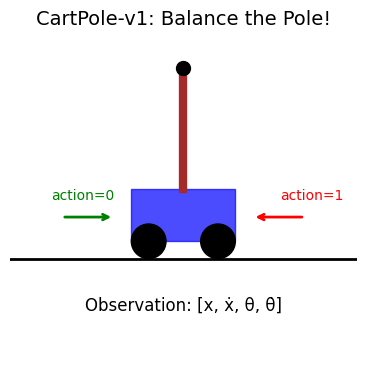

In [8]:
# Visualize CartPole
fig, ax = plt.subplots(figsize=(8, 4))

# Draw cart
cart = plt.Rectangle((0.35, 0.4), 0.3, 0.15, fill=True, color="blue", alpha=0.7)
ax.add_patch(cart)

# Draw pole
ax.plot([0.5, 0.5], [0.55, 0.9], "brown", linewidth=6)
ax.plot([0.5], [0.9], "ko", markersize=10)

# Draw wheels
wheel1 = plt.Circle((0.4, 0.4), 0.05, fill=True, color="black")
wheel2 = plt.Circle((0.6, 0.4), 0.05, fill=True, color="black")
ax.add_patch(wheel1)
ax.add_patch(wheel2)

# Draw track
ax.plot([0, 1], [0.35, 0.35], "k-", linewidth=2)

# Add labels
ax.annotate(
    "",
    xy=(0.3, 0.47),
    xytext=(0.15, 0.47),
    arrowprops={"arrowstyle": "->", "color": "green", "lw": 2},
)
ax.text(0.12, 0.52, "action=0", fontsize=10, color="green")

ax.annotate(
    "",
    xy=(0.7, 0.47),
    xytext=(0.85, 0.47),
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 2},
)
ax.text(0.78, 0.52, "action=1", fontsize=10, color="red")

ax.text(0.5, 0.2, "Observation: [x, ẋ, θ, θ̇]", ha="center", fontsize=12)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("CartPole-v1: Balance the Pole!", fontsize=14)

plt.tight_layout()
plt.show()

## Part 5: Policy Decoding - Genome to Neural Network (FR-042)

In [9]:
class PolicyDecoder:
    """
    Decode a genome (weight vector) into a policy.

    Maps VectorGenome → LinearPolicy or MLPPolicy

    Attributes:
        obs_dim: Observation dimension
        action_dim: Action dimension
        hidden_dims: Tuple of hidden layer sizes (empty for linear)
        discrete: Whether action space is discrete
    """

    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        hidden_dims: tuple[int, ...] = (),
        discrete: bool = True,
        activation: Callable = np.tanh,
    ):
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.hidden_dims = hidden_dims
        self.discrete = discrete
        self.activation = activation

        # Calculate total parameters
        if not hidden_dims:
            self.n_params = obs_dim * action_dim + action_dim
        else:
            dims = [obs_dim] + list(hidden_dims) + [action_dim]
            self.n_params = sum(dims[i] * dims[i + 1] + dims[i + 1] for i in range(len(dims) - 1))

    def decode(self, genome: VectorGenome) -> LinearPolicy | MLPPolicy:
        """
        Convert genome to policy.

        Args:
            genome: VectorGenome with flat weights

        Returns:
            Policy instance
        """
        params = np.array(genome.genes)

        if not self.hidden_dims:
            # Linear policy
            w_size = self.obs_dim * self.action_dim
            weights = params[:w_size].reshape(self.obs_dim, self.action_dim)
            bias = params[w_size:]
            return LinearPolicy(weights=weights, bias=bias, discrete=self.discrete)
        else:
            # MLP policy
            dims = [self.obs_dim] + list(self.hidden_dims) + [self.action_dim]
            weights = []
            biases = []
            idx = 0

            for i in range(len(dims) - 1):
                w_size = dims[i] * dims[i + 1]
                weights.append(params[idx : idx + w_size].reshape(dims[i], dims[i + 1]))
                idx += w_size
                biases.append(params[idx : idx + dims[i + 1]])
                idx += dims[i + 1]

            return MLPPolicy(
                weights=weights, biases=biases, activation=self.activation, discrete=self.discrete
            )


# Create decoder for CartPole
OBS_DIM = 4
ACTION_DIM = 2
HIDDEN_DIMS = (32,)  # One hidden layer with 32 neurons

decoder = PolicyDecoder(
    obs_dim=OBS_DIM, action_dim=ACTION_DIM, hidden_dims=HIDDEN_DIMS, discrete=True
)

print("📊 Policy Decoder Configuration")
print("=" * 50)
print(f"Observation dim: {OBS_DIM}")
print(f"Action dim: {ACTION_DIM}")
print(f"Hidden layers: {HIDDEN_DIMS}")
print(f"Total parameters: {decoder.n_params}")
print(f"\nNetwork: {OBS_DIM} → {HIDDEN_DIMS[0]} → {ACTION_DIM}")

📊 Policy Decoder Configuration
Observation dim: 4
Action dim: 2
Hidden layers: (32,)
Total parameters: 226

Network: 4 → 32 → 2


## Part 6: Episode Rollout as Fitness (FR-043)

In [10]:
def evaluate_policy_single(
    policy: Policy,
    env_factory: Callable,
    seed: int = 42,
    max_steps: int = 500,
    record: bool = False,
) -> RolloutResult:
    """
    Run one episode and return result.

    Args:
        policy: Policy to evaluate
        env_factory: Creates environment instance
        seed: Random seed for reproducibility
        max_steps: Maximum episode length
        record: Whether to record trajectory

    Returns:
        Episode result with total reward
    """
    env = env_factory(seed)
    obs = env.reset(seed=seed)

    total_reward = 0.0
    steps = 0
    observations = [obs.copy()] if record else None
    actions = [] if record else None
    rewards = [] if record else None

    while steps < max_steps:
        action = policy(obs)

        if record:
            actions.append(action)

        obs, reward, done, info = env.step(action)
        total_reward += reward
        steps += 1

        if record:
            observations.append(obs.copy())
            rewards.append(reward)

        if done:
            break

    return RolloutResult(
        total_reward=total_reward,
        episode_length=steps,
        observations=observations,
        actions=actions,
        rewards=rewards,
    )


# Test with random policy
rng = np.random.default_rng(42)
random_genome = VectorGenome(genes=tuple(rng.uniform(-1, 1, decoder.n_params)))
random_policy = decoder.decode(random_genome)

result = evaluate_policy_single(random_policy, create_cartpole_env, seed=42)

print("📊 Random Policy Evaluation")
print("=" * 50)
print(f"Episode return: {result.total_reward:.1f}")
print(f"Episode length: {result.episode_length}")
print("\n⚠️ Random policy typically achieves ~20-50 reward")
print("   Goal: 500 (balance for entire episode)")

📊 Random Policy Evaluation
Episode return: 5.0
Episode length: 6

⚠️ Random policy typically achieves ~20-50 reward
   Goal: 500 (balance for entire episode)


## Part 7: Fitness Aggregation - Bias-Variance Tradeoff (FR-044)

In [11]:
def evaluate_policy_multiple(
    policy: Policy,
    env_factory: Callable,
    n_episodes: int = 5,
    base_seed: int = 42,
    max_steps: int = 500,
    aggregate: str = "mean",
) -> tuple[float, AggregatedResult]:
    """
    Evaluate policy over multiple episodes.

    Args:
        policy: Policy to evaluate
        env_factory: Creates environment instance
        n_episodes: Number of episodes
        base_seed: Starting seed
        max_steps: Maximum episode length
        aggregate: Aggregation method ("mean", "min", "median")

    Returns:
        Tuple of (fitness, detailed results)
    """
    rewards = []
    lengths = []

    for i in range(n_episodes):
        seed = base_seed + i * 1000
        result = evaluate_policy_single(policy, env_factory, seed=seed, max_steps=max_steps)
        rewards.append(result.total_reward)
        lengths.append(result.episode_length)

    # Aggregate
    if aggregate == "mean":
        fitness = np.mean(rewards)
    elif aggregate == "min":
        fitness = np.min(rewards)
    elif aggregate == "median":
        fitness = np.median(rewards)
    else:
        fitness = np.mean(rewards)

    agg_result = AggregatedResult(
        mean_reward=float(np.mean(rewards)),
        std_reward=float(np.std(rewards)),
        min_reward=float(np.min(rewards)),
        max_reward=float(np.max(rewards)),
        mean_length=float(np.mean(lengths)),
        n_episodes=n_episodes,
        all_rewards=rewards,
    )

    return fitness, agg_result


# Compare aggregation methods
print("📊 Fitness Aggregation Comparison")
print("=" * 50)
print("\nEvaluating random policy with 10 episodes...\n")

_, results = evaluate_policy_multiple(random_policy, create_cartpole_env, n_episodes=10)

print(f"Individual rewards: {[f'{r:.1f}' for r in results.all_rewards]}")
print("\nAggregation results:")
print(f"   mean:   {results.mean_reward:.2f}")
print(f"   min:    {results.min_reward:.2f}")
print(f"   median: {np.median(results.all_rewards):.2f}")
print(f"   std:    {results.std_reward:.2f}")

print("\n💡 Insight:")
print("   - 'mean' is standard, good for typical cases")
print("   - 'min' is pessimistic, ensures robust policies")
print("   - 'median' is robust to occasional bad episodes")

📊 Fitness Aggregation Comparison

Evaluating random policy with 10 episodes...

Individual rewards: ['5.0', '6.0', '6.0', '5.0', '7.0', '6.0', '6.0', '6.0', '5.0', '6.0']

Aggregation results:
   mean:   5.80
   min:    5.00
   median: 6.00
   std:    0.60

💡 Insight:
   - 'mean' is standard, good for typical cases
   - 'min' is pessimistic, ensures robust policies
   - 'median' is robust to occasional bad episodes


## Part 8: Running Policy Evolution (FR-045)

In [12]:
class PolicyEvolver:
    """
    Evolve neural network policies for RL tasks.
    """

    def __init__(
        self,
        decoder: PolicyDecoder,
        env_factory: Callable,
        pop_size: int = 50,
        max_generations: int = 50,
        n_episodes: int = 3,
        mutation_rate: float = 0.3,
        mutation_sigma: float = 0.1,
        tournament_size: int = 3,
        elitism: int = 2,
        seed: int = 42,
    ):
        self.decoder = decoder
        self.env_factory = env_factory
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.n_episodes = n_episodes
        self.mutation_rate = mutation_rate
        self.mutation_sigma = mutation_sigma
        self.tournament_size = tournament_size
        self.elitism = elitism
        self.rng = np.random.default_rng(seed)

        self.history = {
            "best_fitness": [],
            "avg_fitness": [],
            "std_fitness": [],
        }
        self.best_genome = None
        self.best_fitness = -float("inf")

    def create_random_genome(self) -> VectorGenome:
        """Create random genome with weights in [-1, 1]."""
        genes = self.rng.uniform(-1, 1, self.decoder.n_params)
        return VectorGenome(genes=tuple(genes))

    def mutate(self, genome: VectorGenome) -> VectorGenome:
        """Gaussian mutation on weights."""
        genes = np.array(genome.genes)

        # Mutate each gene with probability mutation_rate
        mask = self.rng.random(len(genes)) < self.mutation_rate
        genes[mask] += self.rng.normal(0, self.mutation_sigma, np.sum(mask))

        return VectorGenome(genes=tuple(genes))

    def crossover(self, parent1: VectorGenome, parent2: VectorGenome) -> VectorGenome:
        """Uniform crossover."""
        genes1 = np.array(parent1.genes)
        genes2 = np.array(parent2.genes)

        mask = self.rng.random(len(genes1)) < 0.5
        child_genes = np.where(mask, genes1, genes2)

        return VectorGenome(genes=tuple(child_genes))

    def tournament_select(
        self, population: list[VectorGenome], fitnesses: list[float]
    ) -> VectorGenome:
        """Tournament selection."""
        indices = self.rng.choice(len(population), self.tournament_size, replace=False)
        best_idx = indices[np.argmax([fitnesses[i] for i in indices])]
        return population[best_idx]

    def evaluate_population(self, population: list[VectorGenome]) -> list[float]:
        """Evaluate all individuals."""
        fitnesses = []
        for genome in population:
            policy = self.decoder.decode(genome)
            fitness, _ = evaluate_policy_multiple(
                policy,
                self.env_factory,
                n_episodes=self.n_episodes,
                base_seed=int(self.rng.integers(0, 2**30)),
            )
            fitnesses.append(fitness)
        return fitnesses

    def evolve(self, target_fitness: float = 475) -> VectorGenome:
        """
        Run evolution.

        Args:
            target_fitness: Stop when achieved

        Returns:
            Best genome found
        """
        # Initialize population
        population = [self.create_random_genome() for _ in range(self.pop_size)]

        for gen in range(self.max_generations):
            # Evaluate
            fitnesses = self.evaluate_population(population)

            # Track stats
            gen_best = max(fitnesses)
            gen_avg = np.mean(fitnesses)
            gen_std = np.std(fitnesses)

            self.history["best_fitness"].append(gen_best)
            self.history["avg_fitness"].append(gen_avg)
            self.history["std_fitness"].append(gen_std)

            # Track best ever
            best_idx = np.argmax(fitnesses)
            if fitnesses[best_idx] > self.best_fitness:
                self.best_fitness = fitnesses[best_idx]
                self.best_genome = population[best_idx]

            # Progress report
            if gen % 5 == 0 or gen_best >= target_fitness:
                print(f"Gen {gen:3d}: Best={gen_best:.1f}, Avg={gen_avg:.1f}±{gen_std:.1f}")

            # Check for success
            if gen_best >= target_fitness:
                print(f"\n🎉 Target fitness {target_fitness} achieved!")
                break

            # Selection and reproduction
            sorted_indices = np.argsort(fitnesses)[::-1]
            new_population = []

            # Elitism
            for i in range(self.elitism):
                new_population.append(population[sorted_indices[i]])

            # Create offspring
            while len(new_population) < self.pop_size:
                parent1 = self.tournament_select(population, fitnesses)
                parent2 = self.tournament_select(population, fitnesses)

                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                new_population.append(child)

            population = new_population[: self.pop_size]

        return self.best_genome


print("✅ PolicyEvolver class defined")

✅ PolicyEvolver class defined


In [13]:
# Run evolution
print("🧬 Policy Evolution for CartPole-v1")
print("=" * 50)

evolver = PolicyEvolver(
    decoder=decoder,
    env_factory=create_cartpole_env,
    pop_size=50,
    max_generations=30,
    n_episodes=3,
    mutation_rate=0.3,
    mutation_sigma=0.3,
    seed=42,
)

best_genome = evolver.evolve(target_fitness=475)

print(f"\n🏆 Best fitness achieved: {evolver.best_fitness:.1f}")

🧬 Policy Evolution for CartPole-v1
Gen   0: Best=330.3, Avg=14.9±45.4
Gen   5: Best=329.7, Avg=42.5±68.5
Gen   6: Best=500.0, Avg=86.5±120.6

🎉 Target fitness 475 achieved!

🏆 Best fitness achieved: 500.0


## Part 9: Convergence Visualization (FR-015)

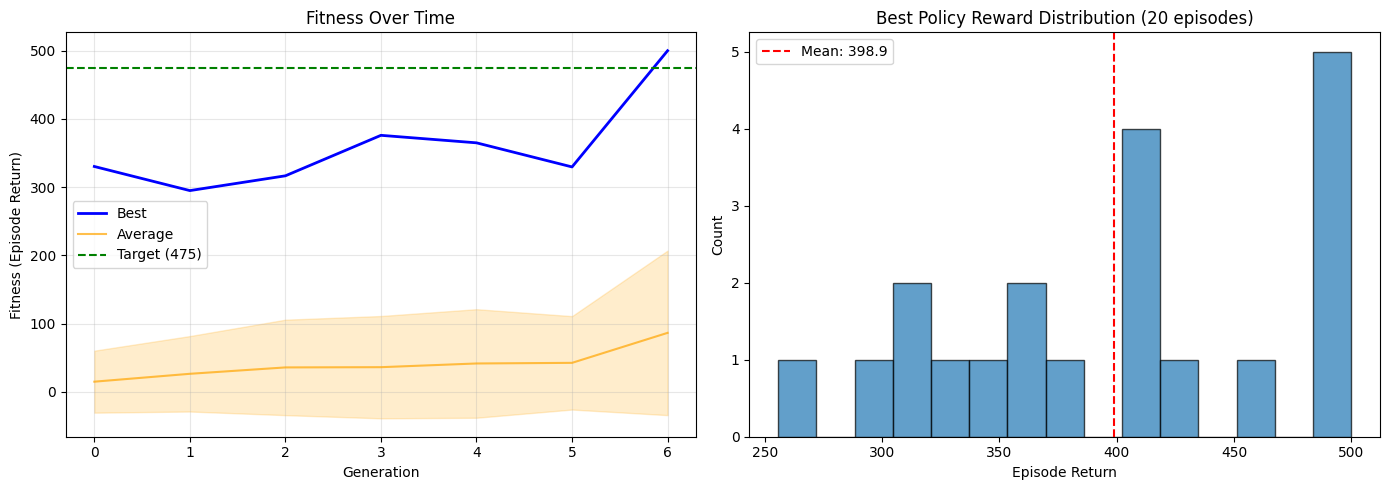

In [14]:
# Plot evolution history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

generations = range(len(evolver.history["best_fitness"]))

# Fitness over time
ax1 = axes[0]
ax1.plot(generations, evolver.history["best_fitness"], "b-", label="Best", linewidth=2)
ax1.plot(generations, evolver.history["avg_fitness"], "orange", label="Average", alpha=0.7)
ax1.fill_between(
    generations,
    np.array(evolver.history["avg_fitness"]) - np.array(evolver.history["std_fitness"]),
    np.array(evolver.history["avg_fitness"]) + np.array(evolver.history["std_fitness"]),
    alpha=0.2,
    color="orange",
)
ax1.axhline(y=475, color="green", linestyle="--", label="Target (475)")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness (Episode Return)")
ax1.set_title("Fitness Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fitness distribution (final generation)
ax2 = axes[1]
final_fitnesses = evolver.evaluate_population([evolver.best_genome] * 20)  # Re-evaluate best
ax2.hist(final_fitnesses, bins=15, edgecolor="black", alpha=0.7)
ax2.axvline(
    x=np.mean(final_fitnesses),
    color="red",
    linestyle="--",
    label=f"Mean: {np.mean(final_fitnesses):.1f}",
)
ax2.set_xlabel("Episode Return")
ax2.set_ylabel("Count")
ax2.set_title("Best Policy Reward Distribution (20 episodes)")
ax2.legend()

plt.tight_layout()
plt.show()

## Part 10: Policy Behavior Visualization (FR-046)

📊 Best Policy Episode Analysis
Episode length: 500
Total return: 500.0


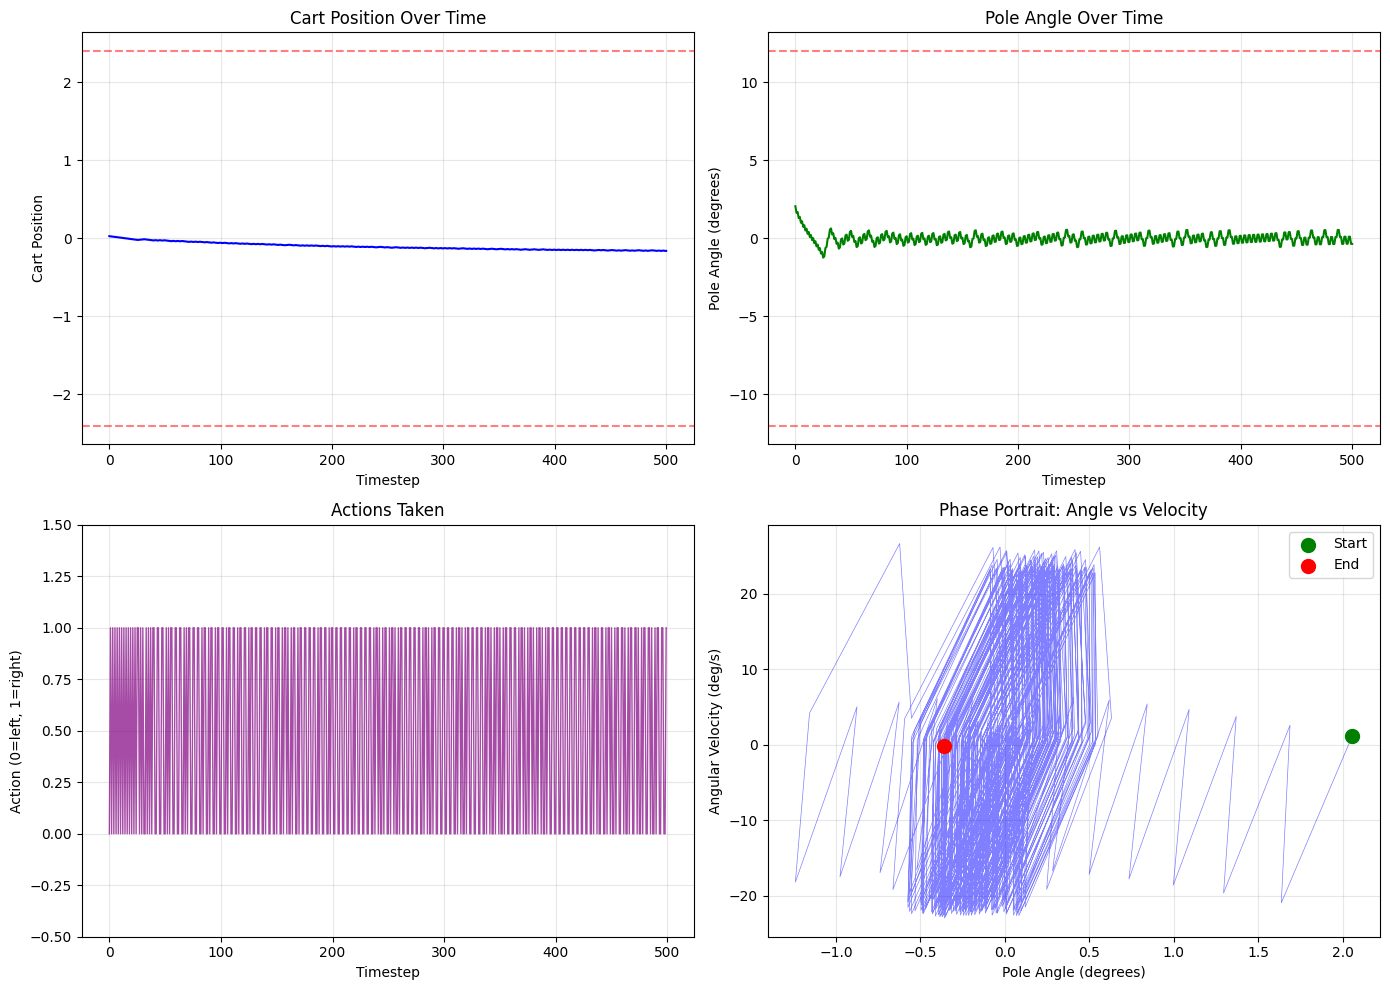

In [15]:
# Visualize best policy behavior
best_policy = decoder.decode(best_genome)
result = evaluate_policy_single(
    best_policy, create_cartpole_env, seed=42, max_steps=500, record=True
)

print("📊 Best Policy Episode Analysis")
print("=" * 50)
print(f"Episode length: {result.episode_length}")
print(f"Total return: {result.total_reward:.1f}")

if result.observations:
    obs_array = np.array(result.observations)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Cart position
    axes[0, 0].plot(obs_array[:, 0], "b-", linewidth=1.5)
    axes[0, 0].axhline(y=2.4, color="red", linestyle="--", alpha=0.5)
    axes[0, 0].axhline(y=-2.4, color="red", linestyle="--", alpha=0.5)
    axes[0, 0].set_xlabel("Timestep")
    axes[0, 0].set_ylabel("Cart Position")
    axes[0, 0].set_title("Cart Position Over Time")
    axes[0, 0].grid(True, alpha=0.3)

    # Pole angle
    axes[0, 1].plot(np.degrees(obs_array[:, 2]), "green", linewidth=1.5)
    axes[0, 1].axhline(y=12, color="red", linestyle="--", alpha=0.5)
    axes[0, 1].axhline(y=-12, color="red", linestyle="--", alpha=0.5)
    axes[0, 1].set_xlabel("Timestep")
    axes[0, 1].set_ylabel("Pole Angle (degrees)")
    axes[0, 1].set_title("Pole Angle Over Time")
    axes[0, 1].grid(True, alpha=0.3)

    # Actions
    if result.actions:
        actions = np.array(result.actions)
        axes[1, 0].plot(actions, "purple", linewidth=1, alpha=0.7)
        axes[1, 0].set_xlabel("Timestep")
        axes[1, 0].set_ylabel("Action (0=left, 1=right)")
        axes[1, 0].set_title("Actions Taken")
        axes[1, 0].set_ylim(-0.5, 1.5)
        axes[1, 0].grid(True, alpha=0.3)

    # Phase plot: angle vs angular velocity
    axes[1, 1].plot(
        np.degrees(obs_array[:, 2]), np.degrees(obs_array[:, 3]), "blue", alpha=0.5, linewidth=0.5
    )
    axes[1, 1].scatter(
        np.degrees(obs_array[0, 2]),
        np.degrees(obs_array[0, 3]),
        c="green",
        s=100,
        zorder=5,
        label="Start",
    )
    axes[1, 1].scatter(
        np.degrees(obs_array[-1, 2]),
        np.degrees(obs_array[-1, 3]),
        c="red",
        s=100,
        zorder=5,
        label="End",
    )
    axes[1, 1].set_xlabel("Pole Angle (degrees)")
    axes[1, 1].set_ylabel("Angular Velocity (deg/s)")
    axes[1, 1].set_title("Phase Portrait: Angle vs Velocity")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Part 11: Comparison with Random Search

📊 Comparison: Evolution vs Random Search

Total evaluations in evolution: ~350
Random sample 0: Best so far = 47.0
Random sample 200: Best so far = 500.0

📊 Results:
   Evolution best:     500.0
   Random search best: 500.0


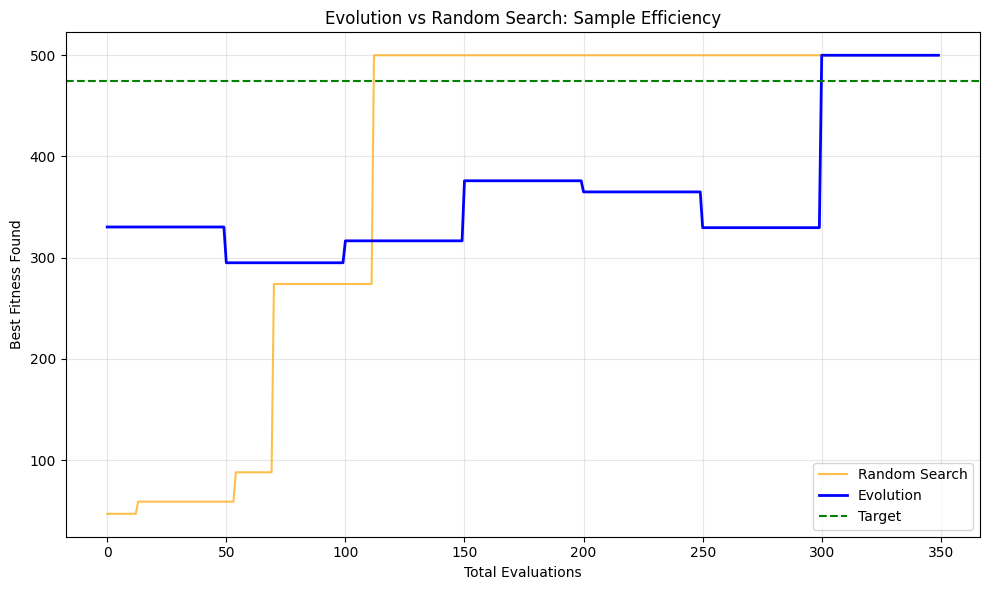

In [16]:
# Compare with random search
print("📊 Comparison: Evolution vs Random Search")
print("=" * 50)

# Random search: same number of evaluations
n_random_samples = evolver.pop_size * len(evolver.history["best_fitness"])
print(f"\nTotal evaluations in evolution: ~{n_random_samples}")

random_best = -float("inf")
random_history = []
rng = np.random.default_rng(123)

for i in range(n_random_samples):
    # Random genome
    genome = VectorGenome(genes=tuple(rng.uniform(-1, 1, decoder.n_params)))
    policy = decoder.decode(genome)
    fitness, _ = evaluate_policy_multiple(
        policy, create_cartpole_env, n_episodes=1, base_seed=int(rng.integers(0, 2**30))
    )

    if fitness > random_best:
        random_best = fitness
    random_history.append(random_best)

    if i % 200 == 0:
        print(f"Random sample {i}: Best so far = {random_best:.1f}")

print("\n📊 Results:")
print(f"   Evolution best:     {evolver.best_fitness:.1f}")
print(f"   Random search best: {random_best:.1f}")

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Evolution (expanded to match evaluation count)
evolution_expanded = []
for gen_best in evolver.history["best_fitness"]:
    evolution_expanded.extend([gen_best] * evolver.pop_size)

ax.plot(range(len(random_history)), random_history, "orange", label="Random Search", alpha=0.7)
ax.plot(range(len(evolution_expanded)), evolution_expanded, "blue", label="Evolution", linewidth=2)

ax.axhline(y=475, color="green", linestyle="--", label="Target")
ax.set_xlabel("Total Evaluations")
ax.set_ylabel("Best Fitness Found")
ax.set_title("Evolution vs Random Search: Sample Efficiency")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 12: Callbacks (FR-017)

In [17]:
class RLCallback:
    """Base callback for RL evolution."""

    def on_generation_end(
        self,
        generation: int,
        best_genome: VectorGenome,
        best_fitness: float,
        population: list[VectorGenome],
    ):
        pass

    def should_stop(self) -> bool:
        return False


class TargetRewardCallback(RLCallback):
    """Stop when target reward is achieved."""

    def __init__(self, target: float = 475):
        self.target = target
        self._should_stop = False

    def on_generation_end(self, _generation, _best_genome, best_fitness, _population):
        if best_fitness >= self.target:
            print(f"\n🎉 Target reward {self.target} achieved!")
            self._should_stop = True

    def should_stop(self):
        return self._should_stop


class WeightStatsCallback(RLCallback):
    """Monitor weight statistics."""

    def __init__(self):
        self.weight_stats = []

    def on_generation_end(self, generation, best_genome, _best_fitness, _population):
        weights = np.array(best_genome.genes)
        self.weight_stats.append(
            {
                "mean": np.mean(weights),
                "std": np.std(weights),
                "min": np.min(weights),
                "max": np.max(weights),
            }
        )
        if generation % 10 == 0:
            print(f"   Weights: mean={np.mean(weights):.3f}, std={np.std(weights):.3f}")


print("✅ RL Callbacks defined")

✅ RL Callbacks defined


## Part 13: Checkpointing (FR-018)

In [18]:
import json


def save_policy_checkpoint(
    genome: VectorGenome, decoder: PolicyDecoder, fitness: float, generation: int, path: str
):
    """Save policy evolution checkpoint."""
    checkpoint = {
        "genes": list(genome.genes),
        "fitness": fitness,
        "generation": generation,
        "decoder_config": {
            "obs_dim": decoder.obs_dim,
            "action_dim": decoder.action_dim,
            "hidden_dims": decoder.hidden_dims,
            "discrete": decoder.discrete,
        },
    }
    with open(path, "w") as f:
        json.dump(checkpoint, f, indent=2)
    print(f"💾 Policy checkpoint saved to {path}")


def load_policy_checkpoint(path: str) -> tuple[VectorGenome, PolicyDecoder, float, int]:
    """Load policy evolution checkpoint."""
    with open(path) as f:
        checkpoint = json.load(f)

    genome = VectorGenome(genes=tuple(checkpoint["genes"]))
    cfg = checkpoint["decoder_config"]
    decoder = PolicyDecoder(
        obs_dim=cfg["obs_dim"],
        action_dim=cfg["action_dim"],
        hidden_dims=tuple(cfg["hidden_dims"]),
        discrete=cfg["discrete"],
    )

    print(
        f"📂 Policy checkpoint loaded: Generation {checkpoint['generation']}, Fitness {checkpoint['fitness']:.1f}"
    )
    return genome, decoder, checkpoint["fitness"], checkpoint["generation"]


# Demonstrate
with tempfile.TemporaryDirectory() as tmpdir:
    ckpt_path = os.path.join(tmpdir, "policy_checkpoint.json")

    save_policy_checkpoint(
        best_genome, decoder, evolver.best_fitness, len(evolver.history["best_fitness"]), ckpt_path
    )

    loaded_genome, loaded_decoder, loaded_fitness, loaded_gen = load_policy_checkpoint(ckpt_path)
    print(f"   Loaded genome with {len(loaded_genome.genes)} parameters")

💾 Policy checkpoint saved to /var/folders/_p/9l79gq556sn9ngc796nx7tn40000gn/T/tmpy6u9dcal/policy_checkpoint.json
📂 Policy checkpoint loaded: Generation 7, Fitness 500.0
   Loaded genome with 226 parameters


## Part 14: Island Model (FR-020, FR-021, FR-022, FR-023)

In [21]:
print("🏝️ Island Model for Policy Evolution")
print("=" * 50)
print("\nBenefits for RL:")
print("   1. Different islands explore different policy structures")
print("   2. Embarrassingly parallel episode evaluation")
print("   3. Migration shares good policies across islands")
print("\nTypical setup: 4 islands × 25 individuals each")

# Configuration
island_config = create_island_config(
    num_islands=4,
    population_per_island=25,
    topology="ring",
    migration_rate=0.1,
    migration_interval=5,
)

print("\n📊 Island Configuration:")
print(f"   Islands: {island_config.num_islands}")
print(f"   Total population: {island_config.total_population}")
print(f"   Topology: {island_config.topology}")
print(f"   Migration every {island_config.migration_interval} generations")

🏝️ Island Model for Policy Evolution

Benefits for RL:
   1. Different islands explore different policy structures
   2. Embarrassingly parallel episode evaluation
   3. Migration shares good policies across islands

Typical setup: 4 islands × 25 individuals each

📊 Island Configuration:
   Islands: 4
   Total population: 100
   Topology: ring
   Migration every 5 generations


## Part 15: GPU Acceleration (FR-024, FR-025, FR-026)

In [22]:
# Check GPU availability
gpu_info = check_gpu_available()
gpu_available = gpu_info.get("available", False) if isinstance(gpu_info, dict) else bool(gpu_info)

print("🖥️ GPU Acceleration for Neuroevolution")
print("=" * 50)
print(f"GPU Available: {gpu_available}")
print(f"Info: {gpu_info}")

print("\n📊 What GPU can accelerate:")
print("   ✓ Vectorized environment stepping (many envs in parallel)")
print("   ✓ Batch policy forward pass")
print("   ✓ Fitness aggregation")
print("   ✗ Genetic operators (typically CPU-bound)")

print("\n💡 Key Libraries:")
print("   - EnvPool: Vectorized environments on GPU")
print("   - JAX/Flax: Fast policy networks")
print("   - CuPy: GPU-accelerated NumPy")

if not gpu_available:
    print("\nℹ️ CPU works well for CartPole (simple dynamics).")
    print("   GPU becomes important for pixel-based observations.")

🖥️ GPU Acceleration for Neuroevolution
GPU Available: False
Info: {'available': False, 'backend': 'cpu', 'device_name': 'CPU', 'message': 'No GPU detected. Running in CPU mode.\nGPU sections will show placeholder benchmarks.\nInstall PyTorch CUDA or JAX with GPU support for acceleration.'}

📊 What GPU can accelerate:
   ✓ Vectorized environment stepping (many envs in parallel)
   ✓ Batch policy forward pass
   ✓ Fitness aggregation
   ✗ Genetic operators (typically CPU-bound)

💡 Key Libraries:
   - EnvPool: Vectorized environments on GPU
   - JAX/Flax: Fast policy networks
   - CuPy: GPU-accelerated NumPy

ℹ️ CPU works well for CartPole (simple dynamics).
   GPU becomes important for pixel-based observations.


## Part 16: Extensions & Next Steps (FR-019)

In [23]:
print("📚 What You've Learned:")
print("=" * 50)
print("1. Neuroevolution uses episode return as fitness")
print("2. Policy = decoded genome (weights → network)")
print("3. Multiple episodes reduce fitness variance")
print("4. Evolution can outperform random search significantly")
print("5. No gradients needed - works with any reward signal!")

print("\n🔬 Experiment Ideas:")
experiments = [
    ("Try different network architectures", "hidden_dims=(32,), (64,), (32, 32)"),
    ("Adjust mutation parameters", "mutation_rate, mutation_sigma"),
    ("Try harder environments", "Acrobot-v1, MountainCar-v0, LunarLander-v2"),
    ("Compare fitness aggregation", "mean vs min vs median"),
    ("Use Evolution Strategies", "OpenAI-ES, CMA-ES variants"),
]
for exp, note in experiments:
    print(f"   • {exp}")
    print(f"     {note}")

📚 What You've Learned:
1. Neuroevolution uses episode return as fitness
2. Policy = decoded genome (weights → network)
3. Multiple episodes reduce fitness variance
4. Evolution can outperform random search significantly
5. No gradients needed - works with any reward signal!

🔬 Experiment Ideas:
   • Try different network architectures
     hidden_dims=(32,), (64,), (32, 32)
   • Adjust mutation parameters
     mutation_rate, mutation_sigma
   • Try harder environments
     Acrobot-v1, MountainCar-v0, LunarLander-v2
   • Compare fitness aggregation
     mean vs min vs median
   • Use Evolution Strategies
     OpenAI-ES, CMA-ES variants


In [24]:
# Advanced section: LunarLander (if gym available)
if GYM_AVAILABLE:
    print("\n🚀 Advanced: LunarLander-v2")
    print("=" * 50)
    print("Observation: 8D (position, velocity, angle, leg contact)")
    print("Actions: 4 discrete (nothing, left, main, right engine)")
    print("Reward: Landing bonus - fuel cost")
    print("\nThis is a harder problem requiring:")
    print("   - Larger networks")
    print("   - More generations")
    print("   - Careful fitness aggregation")
else:
    print("\nℹ️ Install gymnasium for LunarLander-v2 experiments")
    print("   pip install gymnasium[box2d]")


ℹ️ Install gymnasium for LunarLander-v2 experiments
   pip install gymnasium[box2d]


In [25]:
print("\n📚 Continue Your Learning:")
print("=" * 50)

tutorials = [
    ("Tutorial 01", "VectorGenome", "Continuous optimization basics"),
    ("Tutorial 02", "SequenceGenome", "Variable-length, GP"),
    ("Tutorial 03", "GraphGenome/NEAT", "Topology evolution"),
    ("Tutorial 05", "SCMGenome", "Causal discovery, multi-objective"),
]

for tutorial, genome, description in tutorials:
    print(f"   {tutorial}: {genome}")
    print(f"      → {description}\n")


📚 Continue Your Learning:
   Tutorial 01: VectorGenome
      → Continuous optimization basics

   Tutorial 02: SequenceGenome
      → Variable-length, GP

   Tutorial 03: GraphGenome/NEAT
      → Topology evolution

   Tutorial 05: SCMGenome
      → Causal discovery, multi-objective



## Summary

| Concept | RL Equivalent | Key Insight |
|---------|---------------|-------------|
| **Genome** | Policy weights | Flattened neural network |
| **Fitness** | Episode return | No gradients needed |
| **Selection** | Policy ranking | Keep best performers |
| **Mutation** | Weight perturbation | Exploration in weight space |
| **Multi-episode** | MC estimation | Reduces variance |

**Key Insight**: Neuroevolution treats RL as black-box optimization - any reward signal works!